In [88]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("/content/sample_data/creditcard.csv")

# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


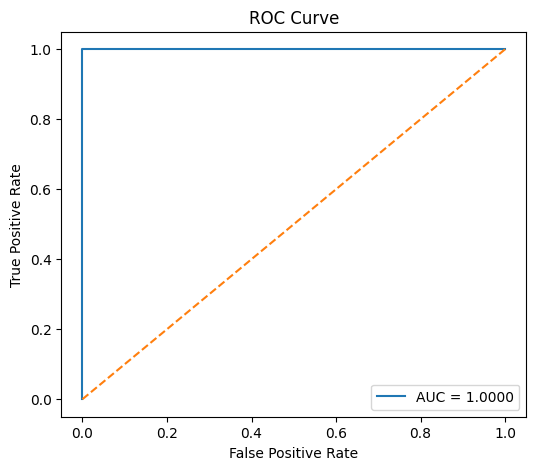

In [89]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

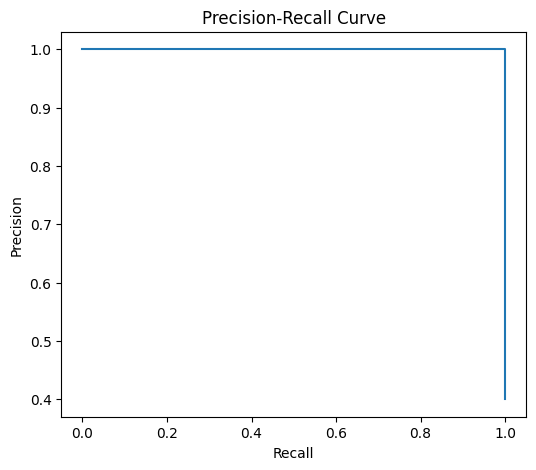

In [90]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [91]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, y_prob)

print("Log Loss:", loss)

Log Loss: 0.015709442830709738


In [93]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Separate positive and negative samples
positive = df[df["Class"] == 1]
negative = df[df["Class"] == 0]

# Keep all positive samples
positive_sample = positive

# Select as many negative samples as available (up to 49 times positives)
num_negatives = min(len(negative), len(positive_sample) * 49)

negative_sample = negative.sample(
    n=num_negatives,
    random_state=42
)

# Combine and shuffle
imbalanced_df = pd.concat([positive_sample, negative_sample])
imbalanced_df = imbalanced_df.sample(frac=1, random_state=42)

# Features and target
X_new = imbalanced_df.drop("Class", axis=1)
y_new = imbalanced_df["Class"]

# Predictions
y_pred_new = model.predict(X_new)
y_prob_new = model.predict_proba(X_new)[:, 1]

# Calculate metrics
acc = accuracy_score(y_new, y_pred_new)

# Calculate AUC only if both classes exist
if len(np.unique(y_new)) > 1:
    auc_score = roc_auc_score(y_new, y_prob_new)
else:
    auc_score = "Cannot calculate (only one class present)"

# Calculate Log Loss
loss = log_loss(y_new, y_prob_new)

print("Accuracy :", acc)
print("AUC :", auc_score)
print("Log Loss :", loss)

Accuracy : 1.0
AUC : 1.0
Log Loss : 0.04014348153832193
